# Spectral Graph Wavelets

For graph Laplacian $L=U\Lambda U^\top$, spectral filtering applies
$$
g(L) = U g(\Lambda) U^\top.
$$
Wavelets localize by choosing band-pass kernels at multiple scales. We show scale effects on a ring graph signal.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/spectral-graph-wavelets/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/spectral-graph-wavelets") if Path("python/spectral-graph-wavelets").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Spectral Graph Wavelets**, with equations and plots designed to expose both the model and the numerical behavior.


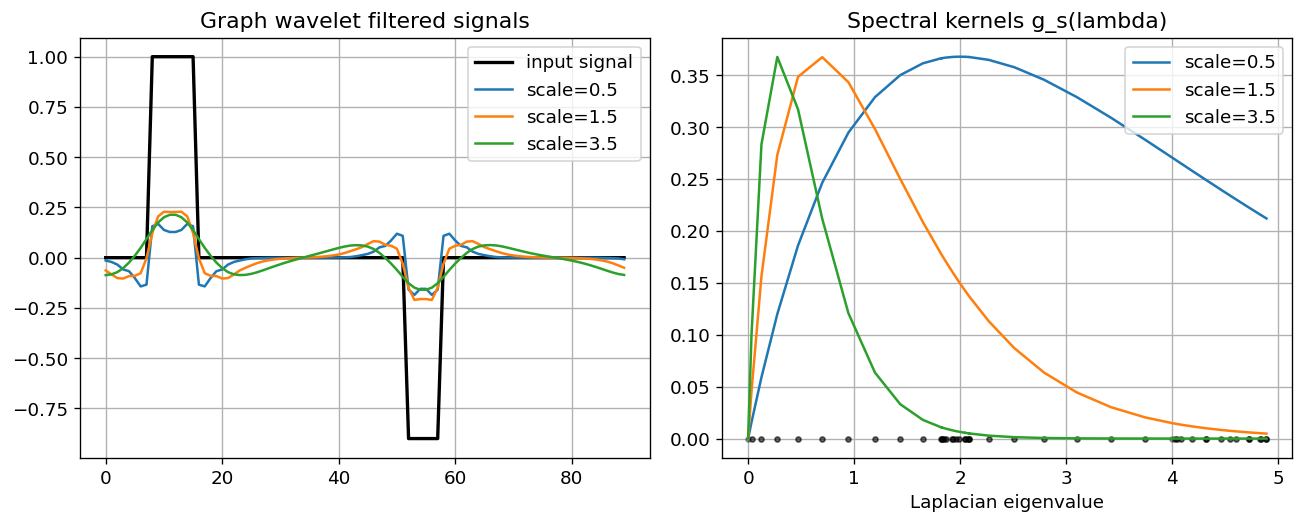

In [2]:
n = 90
W = np.zeros((n, n))
for i in range(n):
    W[i, (i-1) % n] = 1
    W[i, (i+1) % n] = 1
    W[i, (i+4) % n] = 0.35
    W[i, (i-4) % n] = 0.35
D = np.diag(W.sum(axis=1))
L = D - W
evals, U = np.linalg.eigh(L)

f = np.zeros(n)
f[8:16] = 1.0
f[52:58] = -0.9

def wavelet_filter(lam, s):
    return (s * lam) * np.exp(-s * lam)

scales = [0.5, 1.5, 3.5]
filtered = []
for s in scales:
    g = wavelet_filter(evals, s)
    fs = U @ (g * (U.T @ f))
    filtered.append(fs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(f, lw=2, color="k", label="input signal")
for fs, s in zip(filtered, scales):
    axes[0].plot(fs, lw=1.5, label=f"scale={s}")
axes[0].set_title("Graph wavelet filtered signals")
axes[0].legend()

axes[1].plot(evals, np.zeros_like(evals), "k.", alpha=0.35)
for s in scales:
    axes[1].plot(evals, wavelet_filter(evals, s), lw=1.5, label=f"scale={s}")
axes[1].set_title("Spectral kernels g_s(lambda)")
axes[1].set_xlabel("Laplacian eigenvalue")
axes[1].legend()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


### References

- D. K. Hammond, P. Vandergheynst, R. Gribonval, "Wavelets on Graphs via Spectral Graph Theory", *Applied and Computational Harmonic Analysis*, 2011.
- F. Chung, *Spectral Graph Theory*.
